In [181]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

## Section 1: Vectors and matrices operations

In [182]:
def compute_vector_length(vector):
    return np.sqrt(np.sum(vector**2))

def compute_dot_product(vector1, vector2):
    return vector1 @ vector2

def matrix_multi_vector(matrix, vector):
    return matrix @ vector

def matrix_multi_matrix(matrix1, matrix2):
    return matrix1 @ matrix2

## Section 2: Cosine Similarity

In [183]:
def compute_cosine(v1, v2):
    return compute_dot_product(v1, v2) / (compute_vector_length(v1) * compute_vector_length(v2))

## Section 3: Background Subtraction

In [184]:
bg1_image = cv2.imread("data/GreenBackground.png", 1)
bg1_image = cv2.resize(bg1_image, (678, 381))

obj_image = cv2.imread("data/Object.png", 1)
obj_image = cv2.resize(obj_image, (678, 381))

bg2_image = cv2.imread("data/NewBackground.png", 1)
bg2_image = cv2.resize(bg2_image, (678, 381))

In [185]:
def compute_difference(bg_img, input_img):
    difference_single_channel = cv2.absdiff(bg_img, input_img)
    
    return difference_single_channel

In [186]:
def compute_binary_mask(difference_single_channel):
    _, difference_binary = cv2.threshold(difference_single_channel, 0, 255, cv2.THRESH_BINARY)

    return difference_binary

In [187]:
def replace_background(bg1_image, bg2_image, ob_image):
    difference_single_channel = compute_difference(bg1_image, ob_image)

    binary_mask = compute_binary_mask(difference_single_channel)

    plt.imshow(binary_mask)

    output = np.where(binary_mask==0, bg2_image, ob_image)

    return output

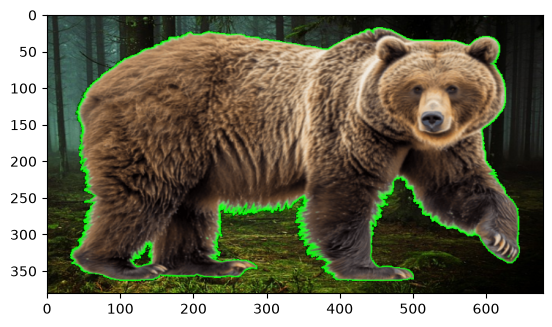

In [188]:
image = replace_background(bg1_image, bg2_image, obj_image)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)) ##I cant seem to use cv2.imshow in this local environment (vscode IDE) so plt is the next best alternative

## Section 4: Multiple-choices Questions

In [189]:
vector = np.array([-2, 4, 9, 21])

q1 = compute_vector_length(vector)
print(round(q1, 2))

23.28


In [190]:
v1 = np.array([0, 1, -1, 2])
v2 = np.array([2, 5, 1, 0])

q2 = compute_dot_product(v1, v2)
print(round(q2, 2))

4


In [191]:
matrix = np.array([[-1, 1, 1], [0, -4, 9]])
vector = np.array([0, 2, 1])

q3 = matrix_multi_vector(matrix, vector)
print(q3)

[3 1]


In [192]:
m1 = np.array([[0, 1, 2], [2, -3, 1]])
m2 = np.array([[1, -3], [6, 1], [0, -1]])

q4 = matrix_multi_matrix(m1, m2)
print(q4)

[[  6  -1]
 [-16 -10]]


In [193]:
x = np.array([1, 2, 3, 4])
y = np.array([1, 0, 3, 0])

q5 = compute_cosine(x, y)
print(round(q5, 3))

0.577


In [194]:
q6_arr = np.arange(0, 10)
print(q6_arr[q6_arr % 2 != 0])

[1 3 5 7 9]


In [195]:
q7_arr = np.arange(0, 10)
print(np.where(q7_arr % 2 != 0, -1, q7_arr))

[ 0 -1  2 -1  4 -1  6 -1  8 -1]


In [196]:
arr1 = np.arange(10).reshape(2, -1)
arr2 = np.ones((2, 5), dtype=int)
c = np.concatenate([arr1, arr2], axis=0)
print(c)

[[0 1 2 3 4]
 [5 6 7 8 9]
 [1 1 1 1 1]
 [1 1 1 1 1]]


In [197]:
arr1 = np.arange(10).reshape(2, -1)
arr2 = np.ones((2, 5), dtype=int)
c = np.concatenate([arr1, arr2], axis=1)

print(c)

[[0 1 2 3 4 1 1 1 1 1]
 [5 6 7 8 9 1 1 1 1 1]]


In [198]:
a = np.array([2, 6, 1, 9, 10, 3, 27])
index = np.where((a >= 5) & (a <=10))[0]
print(a[index])

[ 6  9 10]


In [199]:
import matplotlib.image as mpimg

img = mpimg.imread("data/dog.jpeg")

In [200]:
gray_img_01 = (np.max(img, axis=2) + np.min(img, axis=2)) / 2
print(gray_img_01[0, 0])

102.5


In [201]:
gray_img_02 = np.average(img, axis=2)
print(gray_img_02[0,0])

107.66666666666667


In [202]:
gray_img_03 = 0.21 * img[:, :, 0] + 0.72 * img[:, :, 1] + 0.07 * img[:, :, 2]
print(gray_img_03[0,0])

126.22999999999999


In [203]:
difference_single_channel = compute_difference(bg1_image, obj_image)
print(difference_single_channel.shape)

(381, 678, 3)


In [204]:
def q_15_compute_binary_mask(difference_single_channel):
    binary_mask = (difference_single_channel > 50).astype(np.uint8) * 255
    return binary_mask
difference_single_channel = np.random.rand(678, 381) * 100
binary_mask = q_15_compute_binary_mask(difference_single_channel)
print(binary_mask.dtype)

uint8


In [205]:
df = pd.read_csv("data/advertising.csv")
data = df.to_numpy()
sales = data[:, -1]
tv = data[:, 0]
radio = data[:, 1]
newspaper = data[:, 2]

In [206]:
max_value = np.max(sales)
max_index = np.argmax(sales, axis=0)
print(f"Max: {max_value} - Index: {max_index}")

Max: 27.0 - Index: 175


In [207]:
mean_tv = np.average(tv, axis=0)
print(mean_tv)

147.0425


In [208]:
count = len(sales[sales >= 20])
print(count)

40


In [209]:
index = np.where(sales>=15)
mean_radio = np.average(radio[index])
print(mean_radio)

26.22293577981651


In [211]:
mean_newspaper = np.mean(newspaper)
index2 = np.where(newspaper>mean_newspaper)
sum_sales = np.sum(sales[index2])
print(sum_sales)

1405.1
